# 02 - Sequence-level EDA

In this notebook we explore the labeled dataset before modeling. Central question:
**do protein classes differ in sequence length or amino acid composition?**
If they do, handcrafted features will have signal to work with.

## 1. Setup & load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "labeled_dataset.csv")

# Fixed class order used in every plot for consistent colors/ordering.
CLASS_ORDER = ["enzyme", "dna_rna_binding", "receptor",
               "transporter", "structural", "other"]

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df[["accession", "seq_length", "function_class"]].head()

Rows: 8520
Columns: ['accession', 'entry_name', 'protein_name', 'gene_names', 'organism', 'seq_length', 'sequence', 'function', 'go_ids', 'go_terms', 'ec_numbers', 'keywords', 'function_class']


,accession,seq_length,function_class
0,A0A1B0GTW7,788,enzyme
1,A0JP26,581,other
2,A0PK11,232,transporter
3,A1A4S6,786,structural
4,A1A519,330,dna_rna_binding


## 2. Data integrity

Catch problems that would corrupt modeling later: class balance, duplicate
sequences (leakage risk), and missing annotations per class.

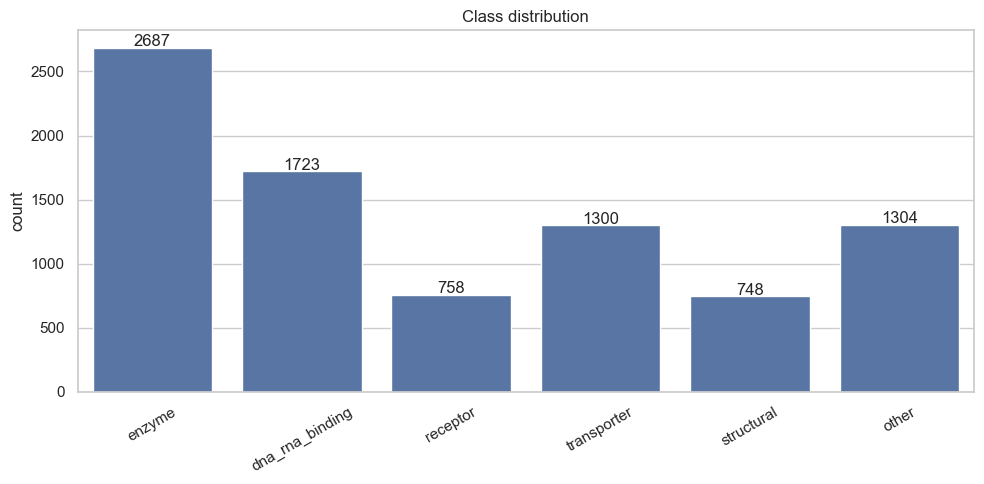

function_class
enzyme             31.5 %
dna_rna_binding    20.2 %
receptor            8.9 %
transporter        15.3 %
structural          8.8 %
other              15.3 %
Name: count, dtype: object


In [3]:
# Class balance
counts = df["function_class"].value_counts().reindex(CLASS_ORDER)

fig, ax = plt.subplots()
sns.barplot(x=counts.index, y=counts.values, order=CLASS_ORDER, ax=ax)
ax.set_title("Class distribution")
ax.set_xlabel("")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()

print((counts / len(df) * 100).round(1).astype(str) + " %")

In [4]:
# Duplicate sequences — identical sequences leak across train/test splits.
dup_mask = df["sequence"].duplicated(keep=False)
n_dup_rows = dup_mask.sum()
n_unique_seqs = df["sequence"].nunique()

print(f"Total rows:               {len(df)}")
print(f"Unique sequences:         {n_unique_seqs}")
print(f"Rows in duplicate groups: {n_dup_rows}")

if n_dup_rows > 0:
    # Do duplicates ever cross class boundaries? (worst case for labels)
    cross = (
        df[dup_mask]
        .groupby("sequence")["function_class"]
        .nunique()
        .gt(1)
        .sum()
    )
    print(f"Duplicate sequences with >1 class label: {cross}")

Total rows:               8520
Unique sequences:         8513
Rows in duplicate groups: 13
Duplicate sequences with >1 class label: 0


In [5]:
# Missing GO / EC annotations per class — how well-annotated is each class?
missing = (
    df.assign(
        no_go=df["go_terms"].isna(),
        no_ec=df["ec_numbers"].isna(),
    )
    .groupby("function_class")[["no_go", "no_ec"]]
    .mean()
    .reindex(CLASS_ORDER)
    .mul(100)
    .round(1)
)
missing.columns = ["% missing GO", "% missing EC"]
missing

,% missing GO,% missing EC
function_class,,
enzyme,0.0,9.0
dna_rna_binding,0.0,100.0
receptor,0.0,100.0
transporter,0.0,100.0
structural,0.0,100.0
other,2.4,100.0


## 3. Sequence length analysis

Does protein size differ by class? Length is the simplest possible feature, so
if it separates classes at all, the baseline already has something to learn.

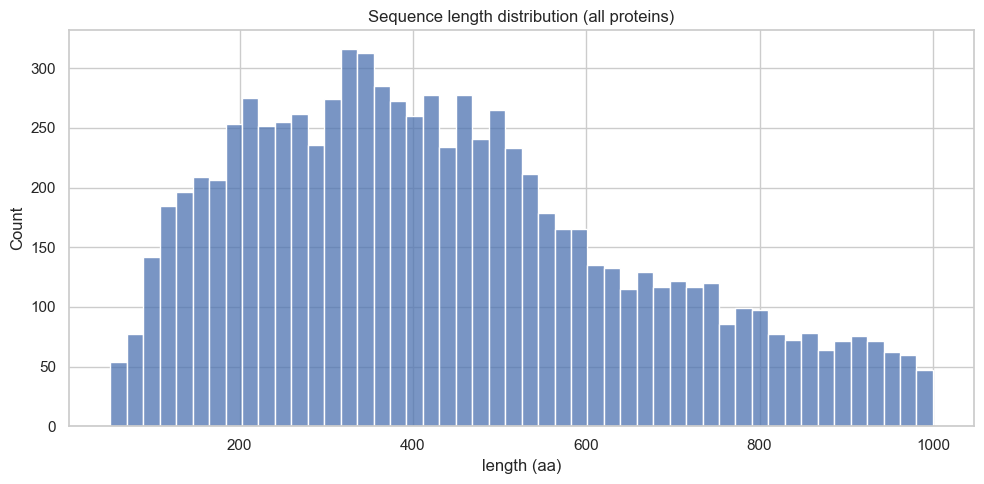

count    8520.0
mean      438.1
std       224.7
min        51.0
25%       261.0
50%       406.0
75%       580.2
max      1000.0
Name: seq_length, dtype: float64

In [6]:
# Overall length distribution
fig, ax = plt.subplots()
sns.histplot(df["seq_length"], bins=50, ax=ax)
ax.set_title("Sequence length distribution (all proteins)")
ax.set_xlabel("length (aa)")
plt.tight_layout()
plt.savefig(FIG_DIR / "length_histogram.png", dpi=150)
plt.show()

df["seq_length"].describe().round(1)

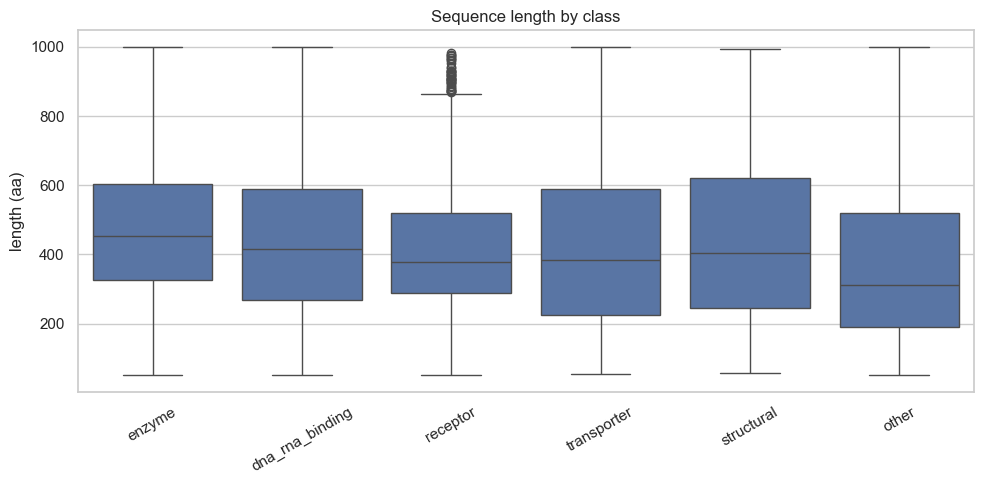

function_class
enzyme             454.0
dna_rna_binding    417.0
receptor           377.5
transporter        383.0
structural         403.0
other              312.5
Name: seq_length, dtype: float64

In [7]:
# Length by class 
fig, ax = plt.subplots()
sns.boxplot(data=df, x="function_class", y="seq_length",
            order=CLASS_ORDER, ax=ax)
ax.set_title("Sequence length by class")
ax.set_xlabel("")
ax.set_ylabel("length (aa)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "length_by_class.png", dpi=150)
plt.show()

df.groupby("function_class")["seq_length"].median().reindex(CLASS_ORDER)

### Interpretation:
**Sequence length distribution**
The data is roughly unimodal with a peak around 300–400 aa and a long right tail thinning out toward the 1000 aa cutoff. There's a sharp floor at 50 aa (lower bound) and the tail is truncated at 1000 aa (the ESM-driven upper bound). Nothing pathological — no spike of tiny fragments, no second hidden mode — which means length is a well-behaved feature with no preprocessing surprises.

**Sequence length by class**
The key takeaway is that length carries weak class signal. Median lengths cluster tightly across classes, and every box overlaps heavily with every other. Two modest patterns stand out: other skews shortest (median ~310, lower box), and enzyme/structural skew slightly longer. The receptor class shows a cluster of high outliers above ~850 aa, consistent with large multi-domain receptors.

**What this means for modeling**
Length alone will not separate these classes — the overlap is too large for any single-feature split to work. That's an expected and useful finding.

## 4. Amino acid composition analysis

Fraction of each of the 20 amino acids per sequence, averaged by class. This is
where biochemical differences show up - e.g. membrane proteins (transporters)
tend to be richer in hydrophobic residues (A, I, L, V, F, M).

In [8]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(seq):
    """Return fraction of each amino acid in a sequence."""
    n = len(seq)
    counts = Counter(seq)
    return {aa: counts.get(aa, 0) / n for aa in AMINO_ACIDS}

# Build a composition DataFrame (one column per amino acid).
comp = pd.DataFrame(df["sequence"].apply(aa_composition).tolist(),
                    index=df.index)
comp["function_class"] = df["function_class"].values
comp.head()

,A,C,D,E,F,G,H,I,K,L,...,N,P,Q,R,S,T,V,W,Y,function_class
0,0.068528,0.036802,0.034264,0.044416,0.024112,0.090102,0.038071,0.021574,0.032995,0.143401,...,0.017766,0.077411,0.050761,0.050761,0.096447,0.060914,0.053299,0.016497,0.025381,enzyme
1,0.053356,0.037866,0.063683,0.092943,0.015491,0.056799,0.034423,0.036145,0.092943,0.104991,...,0.060241,0.027539,0.051635,0.049914,0.080895,0.037866,0.046472,0.008606,0.017212,other
2,0.107759,0.021552,0.021552,0.051724,0.064655,0.073276,0.021552,0.081897,0.043103,0.133621,...,0.025862,0.030172,0.038793,0.025862,0.056034,0.030172,0.107759,0.021552,0.025862,transporter
3,0.058524,0.013995,0.047074,0.090331,0.053435,0.049618,0.026718,0.045802,0.077608,0.090331,...,0.044529,0.063613,0.043257,0.055980,0.080153,0.053435,0.052163,0.008906,0.021628,structural
4,0.030303,0.030303,0.030303,0.148485,0.018182,0.066667,0.027273,0.015152,0.054545,0.054545,...,0.027273,0.054545,0.063636,0.063636,0.121212,0.066667,0.066667,0.012121,0.015152,dna_rna_binding


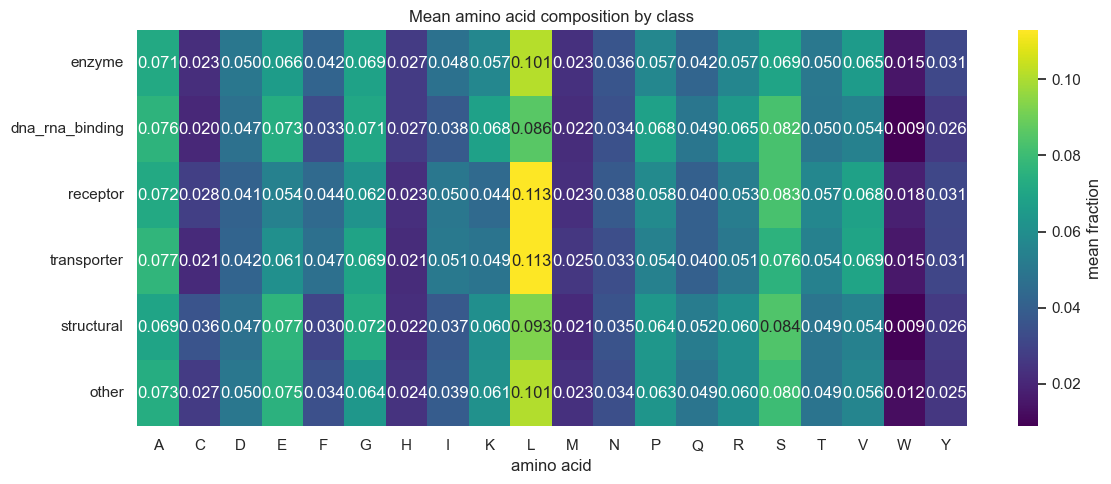

In [9]:
# Mean composition per class -> heatmap.
mean_comp = (
    comp.groupby("function_class")[AMINO_ACIDS]
    .mean()
    .reindex(CLASS_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(mean_comp, annot=True, fmt=".3f", cmap="viridis",
            cbar_kws={"label": "mean fraction"}, ax=ax)
ax.set_title("Mean amino acid composition by class")
ax.set_xlabel("amino acid")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "aa_composition_heatmap.png", dpi=150)
plt.show()

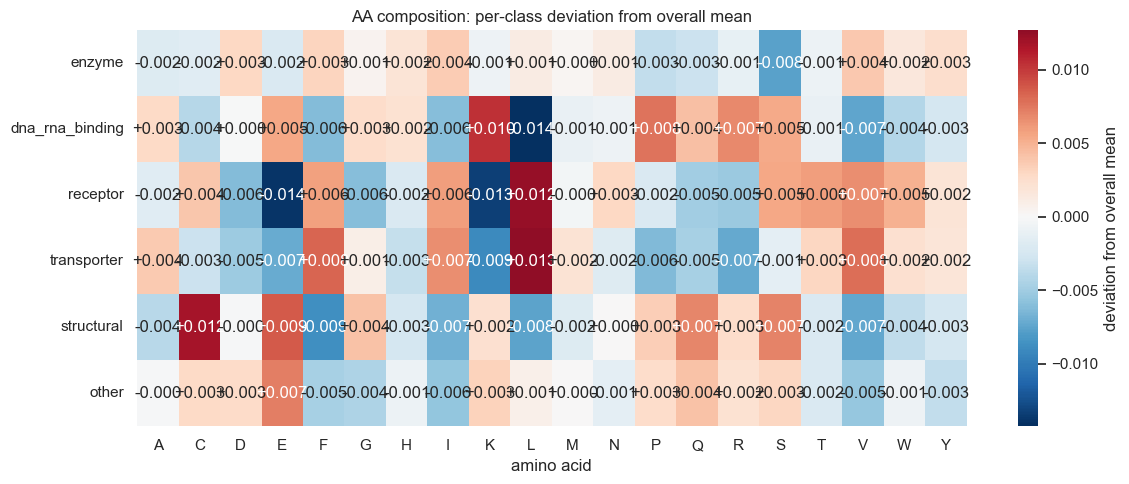

In [10]:
# Highlights which residues make a class distinctive.
overall = comp[AMINO_ACIDS].mean()
deviation = mean_comp - overall

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(deviation, annot=True, fmt="+.3f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "deviation from overall mean"}, ax=ax)
ax.set_title("AA composition: per-class deviation from overall mean")
ax.set_xlabel("amino acid")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "aa_composition_deviation.png", dpi=150)
plt.show()

## 5. Summary of findings

Fill this in after running the cells above. Note for each:

- **Class balance:** mild imbalance (~3.6:1). Use stratified splits + macro-F1.
- **Duplicates:** how many, and do any cross class labels? Decide whether to drop.
- **Length:** which classes are larger/smaller? Does length look usable?
- **Composition:** which residues distinguish which classes? (e.g. hydrophobic
  residues in transporters). These are the features the Day 4 baseline will lean on.
